In [2]:
import pandas as pd

# Lire seulement 500 000 lignes — suffisant pour le projet
df = pd.read_json(
    "C:\\Users\\asus\\projet-reco\\data\\raw\\Electronics_5.json\\Electronics_5.json",
    lines=True,
    chunksize=100000
)

# Prendre seulement les 5 premiers chunks = 500 000 lignes
chunks = []
for i, chunk in enumerate(df):
    chunks.append(chunk)
    if i == 9:
        break

df = pd.concat(chunks, ignore_index=True)
print(f"Lignes chargées : {len(df):,}")



Lignes chargées : 1,000,000


In [3]:
df = df[['reviewerID', 'asin', 'overall']]
df.columns = ['user_id', 'product_id', 'rating']
print(f"Colonnes : {df.columns.tolist()}")
df.head()

Colonnes : ['user_id', 'product_id', 'rating']


,user_id,product_id,rating
0,AAP7PPBU72QFM,0151004714,5
1,A2E168DTVGE6SV,0151004714,3
2,A1ER5AYS3FQ9O3,0151004714,5
3,A1T17LMQABMBN5,0151004714,5
4,A3QHJ0FXK33OBE,0151004714,3


In [4]:
print(f"Avant nettoyage : {len(df):,} lignes")
df = df.dropna()
df = df.drop_duplicates()
df['rating'] = df['rating'].astype(float)
print(f"Après nettoyage : {len(df):,} lignes")

Avant nettoyage : 1,000,000 lignes
Après nettoyage : 886,237 lignes


In [5]:
user_counts = df['user_id'].value_counts()
df = df[df['user_id'].isin(user_counts[user_counts >= 5].index)]

product_counts = df['product_id'].value_counts()
df = df[df['product_id'].isin(product_counts[product_counts >= 5].index)]

print(f"Après filtrage : {len(df):,} lignes")
print(f"Utilisateurs   : {df['user_id'].nunique():,}")
print(f"Produits       : {df['product_id'].nunique():,}")

Après filtrage : 218,574 lignes
Utilisateurs   : 32,604
Produits       : 8,753


In [6]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
product_enc = LabelEncoder()

df['user_id'] = user_enc.fit_transform(df['user_id'])
df['product_id'] = product_enc.fit_transform(df['product_id'])

print("IDs convertis en numérique ✓")
df.head()

IDs convertis en numérique ✓


,user_id,product_id,rating
16,21935,0,2.0
21,13014,0,5.0
26,641,0,4.0
36,3194,0,5.0
46,11981,0,5.0


In [7]:
print("=== RÉSUMÉ DU DATASET ===")
print(f"Nb utilisateurs  : {df['user_id'].nunique():,}")
print(f"Nb produits      : {df['product_id'].nunique():,}")
print(f"Nb interactions  : {len(df):,}")
print(f"Moyenne ratings  : {df['rating'].mean():.2f}")
print(f"Min rating       : {df['rating'].min()}")
print(f"Max rating       : {df['rating'].max()}")

=== RÉSUMÉ DU DATASET ===
Nb utilisateurs  : 32,604
Nb produits      : 8,753
Nb interactions  : 218,574
Moyenne ratings  : 4.33
Min rating       : 1.0
Max rating       : 5.0


C:\Users\asus\AppData\Local\Temp\ipykernel_20900\3011117211.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='Blues_d')


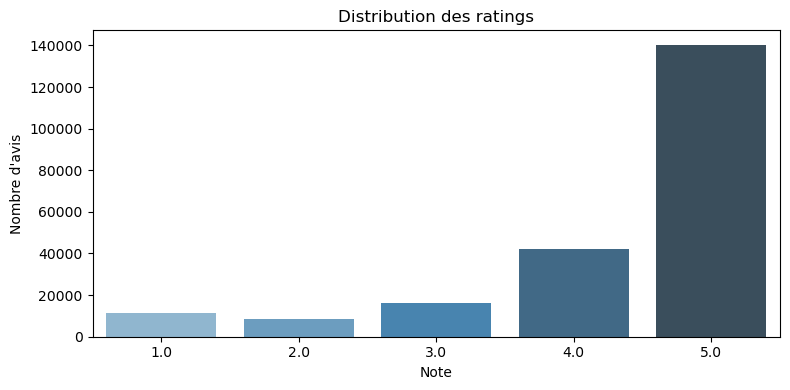

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(x='rating', data=df, palette='Blues_d')
plt.title("Distribution des ratings")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.tight_layout()
plt.savefig("../reports/rating_distribution.png", dpi=150)
plt.show()

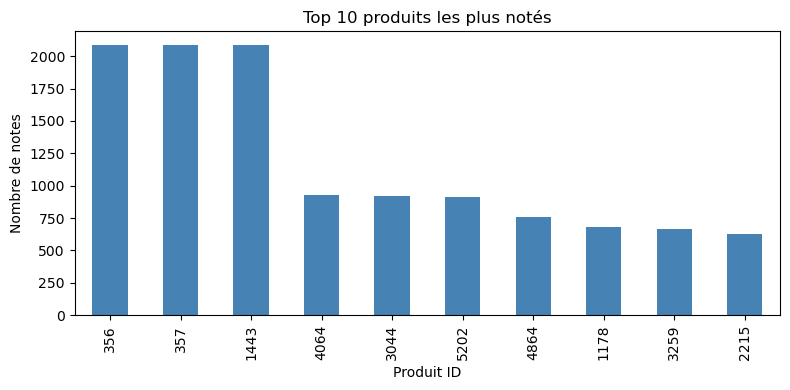

In [9]:
top10 = df['product_id'].value_counts().head(10)

plt.figure(figsize=(8, 4))
top10.plot(kind='bar', color='steelblue')
plt.title("Top 10 produits les plus notés")
plt.xlabel("Produit ID")
plt.ylabel("Nombre de notes")
plt.tight_layout()
plt.savefig("../reports/top_products.png", dpi=150)
plt.show()

In [10]:
df.to_csv("../data/processed/ratings_clean.csv", index=False)

# Vérification
test = pd.read_csv("../data/processed/ratings_clean.csv")
print(f"✓ Fichier exporté : {len(test):,} lignes")
print(f"Colonnes : {test.columns.tolist()}")
test.head()

✓ Fichier exporté : 218,574 lignes
Colonnes : ['user_id', 'product_id', 'rating']


,user_id,product_id,rating
0,21935,0,2.0
1,13014,0,5.0
2,641,0,4.0
3,3194,0,5.0
4,11981,0,5.0


In [11]:
summary = f"""
=== DATA SUMMARY — Amazon Electronics ===

Nb utilisateurs  : {df['user_id'].nunique():,}
Nb produits      : {df['product_id'].nunique():,}
Nb interactions  : {len(df):,}
Moyenne ratings  : {df['rating'].mean():.2f}

Colonnes finales :
  - user_id     (int)
  - product_id  (int)
  - rating      (float)

Fichier livré : data/processed/ratings_clean.csv
"""

with open("../reports/data_summary.txt", "w") as f:
    f.write(summary)

print(summary)


=== DATA SUMMARY — Amazon Electronics ===

Nb utilisateurs  : 32,604
Nb produits      : 8,753
Nb interactions  : 218,574
Moyenne ratings  : 4.33

Colonnes finales :
  - user_id     (int)
  - product_id  (int)
  - rating      (float)

Fichier livré : data/processed/ratings_clean.csv



In [12]:
import pandas as pd

df_check = pd.read_csv("../data/processed/ratings_clean.csv")
print(f"Shape : {df_check.shape}")
df_check.head(10)

Shape : (218574, 3)


,user_id,product_id,rating
0,21935,0,2.0
1,13014,0,5.0
2,641,0,4.0
3,3194,0,5.0
4,11981,0,5.0
5,30946,1,3.0
6,32271,1,5.0
7,2419,1,5.0
8,16700,1,4.0
9,22450,1,5.0
